In [3]:

import torch
import numpy as np
from tqdm.autonotebook import tqdm
from matplotlib import pyplot as plt
import torch.nn.functional as F
import torch.nn as nn
import warnings
import copy
from collections import deque
from torch.distributions import Categorical
import pandas as pd

try:
    import wandb
    WANDB_AVAILABLE = True
except ImportError:
    WANDB_AVAILABLE = False

from model import *
from utils import *
from env import *
from ppo import *

log_wandb = True

import datetime


now = datetime.datetime.now()   
curr_time = now.strftime("%H_%M_%S")
curr_date = now.strftime("%d_%m_%Y")
curr_date_time = str('d_')+curr_date+str('_t_')+curr_time

In [4]:
PROJECT_NAME = "Bio Env"
# RUN_NAME = (
#     EXPERIMENT_PARAMS["AGENT_NAME"]
#     + "_Run_" + str(EXPERIMENT_PARAMS["RUN_NUM"])
#     + "_Seed_" + str(EXPERIMENT_PARAMS["SEED"])
# )

RUN_NAME = "Run 3"
if log_wandb:
    print(f'Running project {PROJECT_NAME}, run {RUN_NAME} on wandb at curr date and time {curr_date_time}')
    wandb.init(
            project=PROJECT_NAME,
            name=RUN_NAME,
            # config={
            #     "experiment_params": EXPERIMENT_PARAMS,
            #     "agent": AGENT_NAME,
            #     "agent_args": AGENT_ARGS,
            #     "training_params": TRAINING_PARAMS,
            #     "env_args": ENV_AGRS,
            #     "device": torch.device("cuda" if torch.cuda.is_available() else "cpu"),
            #     "file_path": FILE_PATH,
            #     "datetime": curr_date_time,
            # }
            )

Running project Bio Env, run Run 3 on wandb at curr date and time d_22_05_2026_t_21_39_56


wandb: Currently logged in as: charithapalika (charitha_palika) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [5]:

# ──────────────────────────────────────────────────────────────────────────────
# Quick smoke-test  (python ppo.py)
# ──────────────────────────────────────────────────────────────────────────────

# if __name__ == "__main__":
#     import sys, os
#     sys.path.insert(0, os.path.dirname(os.path.abspath(__file__)))

from env import FoodEnv

# ── Config ────────────────────────────────────────────────────────────────
# NUTRIENT_CONFIG in bio_env.py drives which nutrients are active.
# Edit that dict to add/remove nutrients; no changes needed here.
FOOD_FOLDER = "/Users/charithapalika/Desktop/Lab projects/Appetite modelling/Single_agent_model/BioEnvWork/foods_dataset"       # directory containing nutrient CSVs
PLOT_DIR    = "plots"
MENU_SIZE   = 2 #2
MAX_STEPS   = 480 #720 #100 # 480 ~ 16 hrs
SEED        = 0 #2000

os.makedirs(PLOT_DIR, exist_ok=True)

# ── Environment ───────────────────────────────────────────────────────────
# All nutrient-specific config (decay, window, target, reward weight) is
# read from NUTRIENT_CONFIG in bio_env.py automatically.
env = FoodEnv(
    food_folder=FOOD_FOLDER,
    num_foods=MENU_SIZE,
    max_steps=MAX_STEPS,
    one_hot_embedding=True,
    seed=SEED,
)

print("\n── Environment summary ──────────────────────────────────────")
print(f"  Food items      : {env.num_items}")
print(f"  Nutrients       : {env.num_nutrients}  {env.nutrient_names}")
print(f"  Menu size       : {env.num_foods}  (+1 skip → {env.action_space.n} actions)")
print(f"  Max steps       : {env.max_steps}")
print(f"  Target (normed) : {env._norm_targets}")
print()
print(env.nutrient_norm_summary().to_string(index=False))
print("─────────────────────────────────────────────────────────────\n")

# ── Train ─────────────────────────────────────────────────────────────────
agent = PPOAgent(env, device="cpu", shared=False, seed=42, limit_delta = 1.0)
NUM_EPISODES = 750
print(f"Starting training: {NUM_EPISODES} …")
returns, eaten = agent.train(
    num_episodes=NUM_EPISODES,
    rollout_steps=128,
    ppo_epochs=4,
    minibatch_size=32,
    log_every_episodes=1,
    printing=True,
    actor_lr=1e-4,
    critic_lr=1e-2,
    log_wandb= True
)
print(f"\nDone. Final rolling avg return (last 50): {np.mean(returns[-50:]):.3f}")


[FoodEnv] Loading  'glucose'  from  '/Users/charithapalika/Desktop/Lab projects/Appetite modelling/Single_agent_model/BioEnvWork/foods_dataset/serum_glucose.csv'
           min=0.0000  max=153.4313   foods=28   time_points=500
[FoodEnv] Loading  'peptides'  from  '/Users/charithapalika/Desktop/Lab projects/Appetite modelling/Single_agent_model/BioEnvWork/foods_dataset/small_peptides_absorbed.csv'
           min=0.0000  max=0.0018   foods=28   time_points=500
[FoodEnv] Loading  'fatty_acids'  from  '/Users/charithapalika/Desktop/Lab projects/Appetite modelling/Single_agent_model/BioEnvWork/foods_dataset/fatty_acids_absorbed.csv'
           min=0.0000  max=0.0049   foods=28   time_points=500
[FoodEnv] Ready — 28 foods | 3 time-series nutrients | 0 cumulative nutrients

── Environment summary ──────────────────────────────────────
  Food items      : 28
  Nutrients       : 3  ['glucose', 'peptides', 'fatty_acids']
  Menu size       : 2  (+1 skip → 3 actions)
  Max steps       : 480
  Targ


Running greedy evaluation episode for plots …
  Saved evaluation_summary.png
  Saved digestion_dynamics.png

All plots saved to 'plots/'


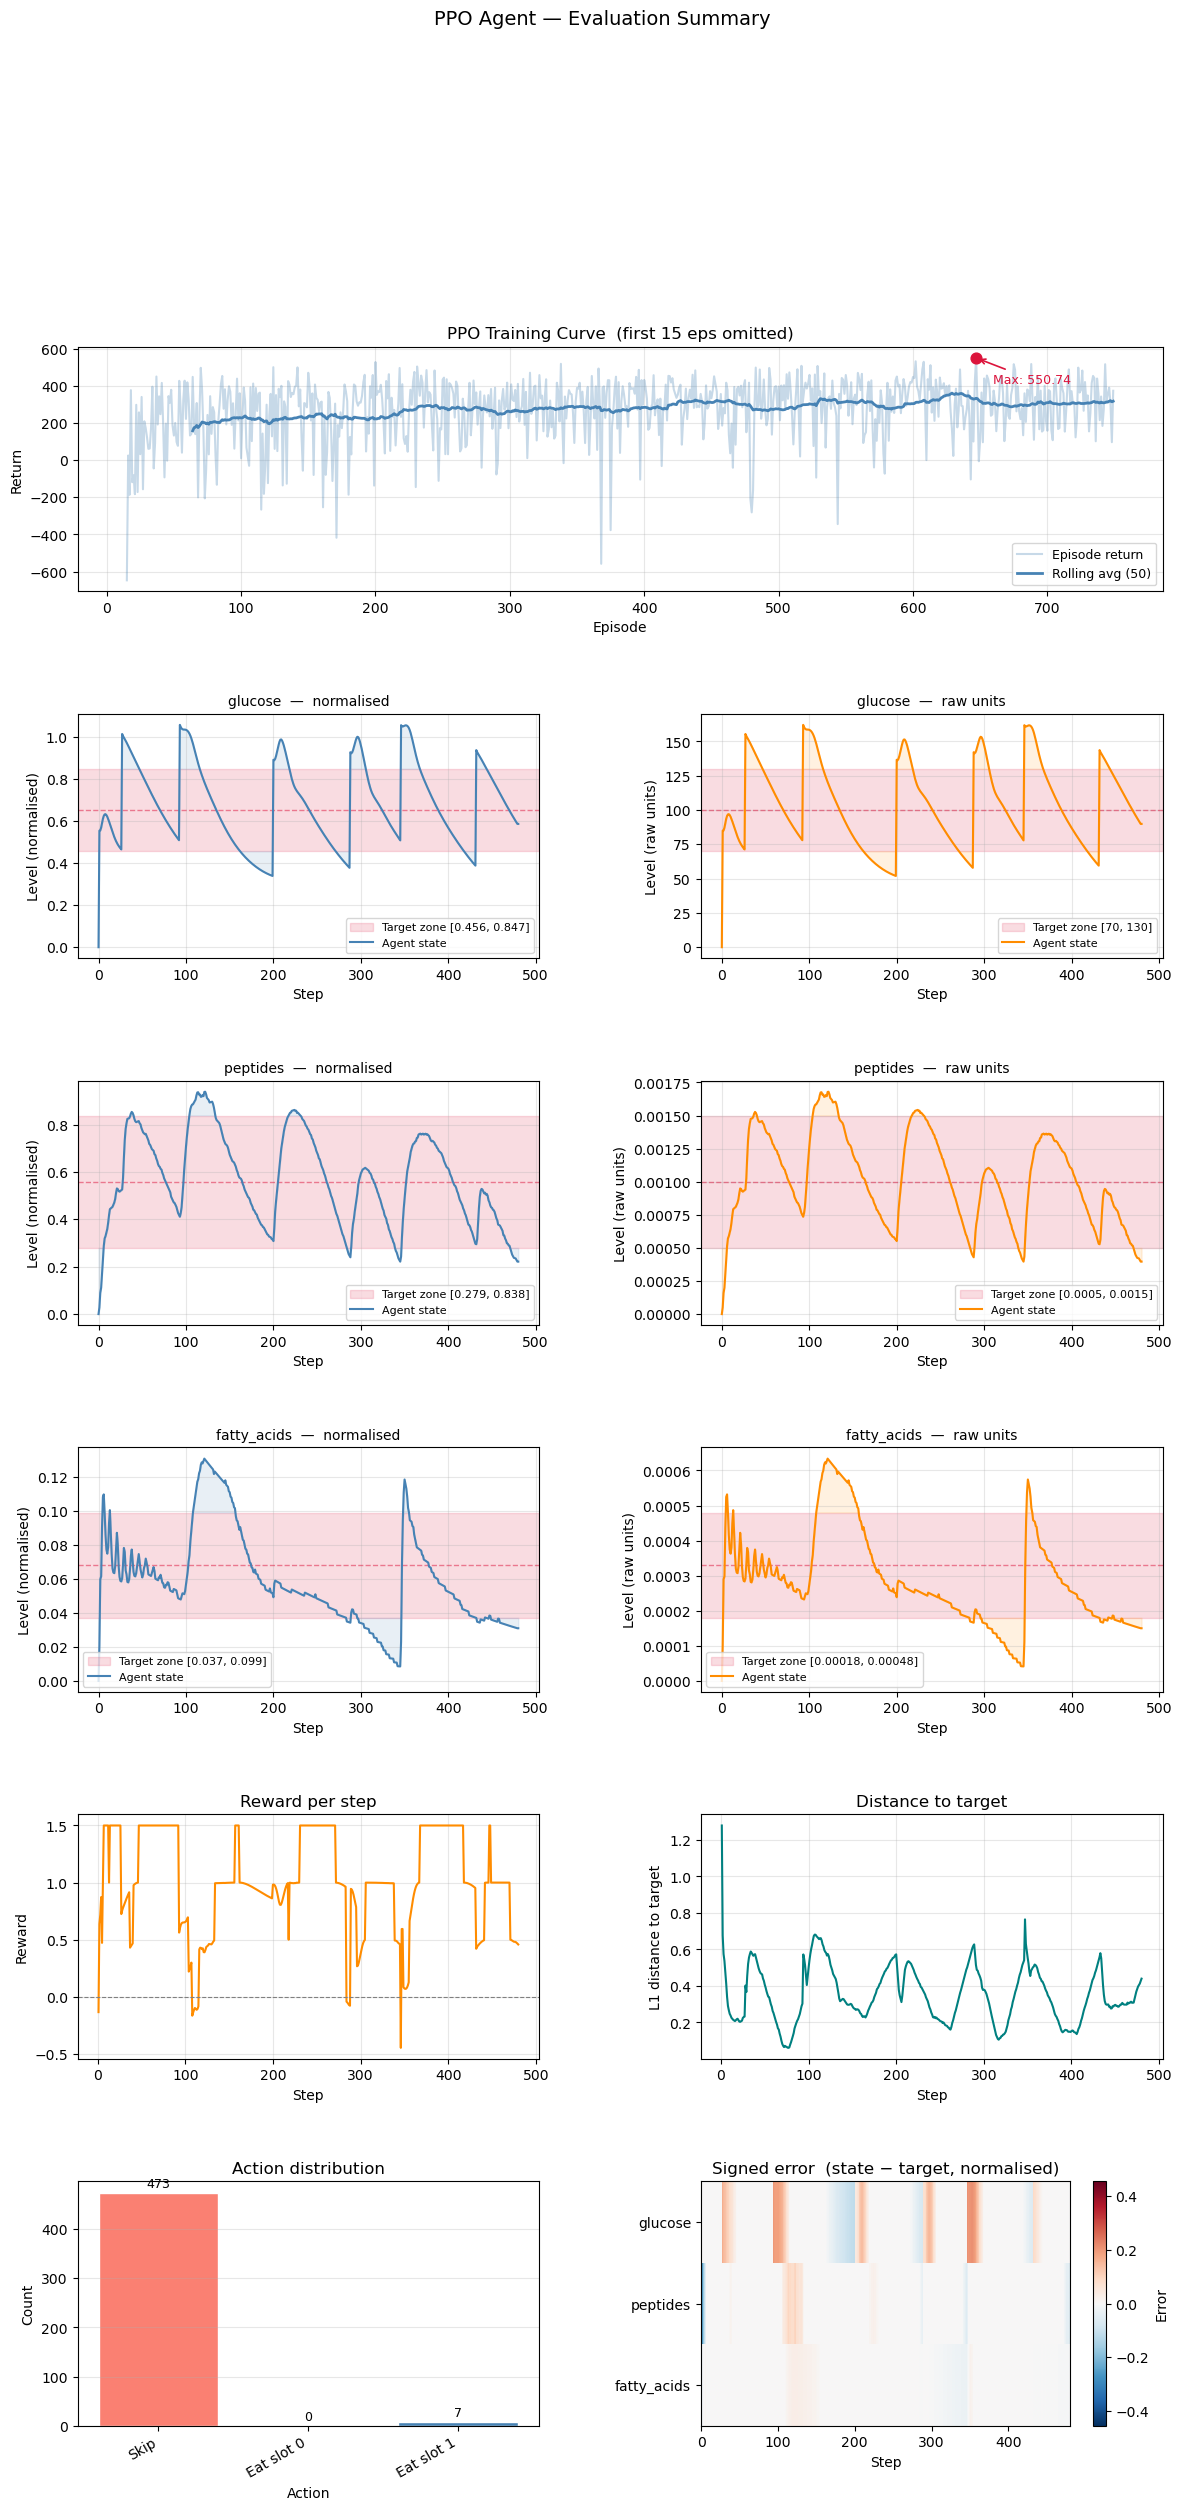

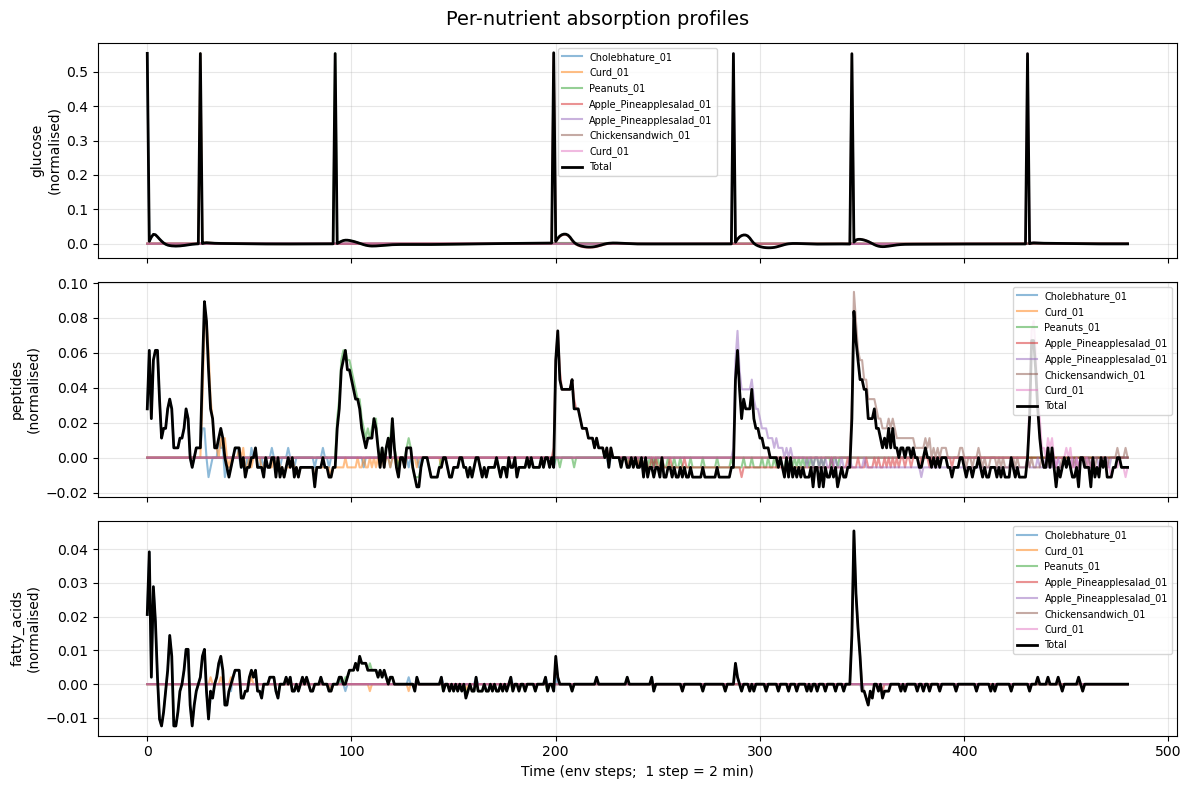

In [13]:

# ── Post-training: run one greedy episode for diagnostics ─────────────────
print("\nRunning greedy evaluation episode for plots …")
memory, episode_df = agent.generate_episode(log_wandb=True)

# Reconstruct traj dict in the same format run_and_plot_env.py uses
T         = len(episode_df)
states    = np.vstack([
    episode_df[[n for n in env.nutrient_names]].values,
    # append final state (last row repeated as terminal step placeholder)
    episode_df[[n for n in env.nutrient_names]].iloc[[-1]].values,
])                                                          # (T+1, N)
actions   = episode_df["action"].values                    # (T,)
rewards   = episode_df["reward"].values                    # (T,)
distances = episode_df["distance"].values                  # (T,)
menus     = np.zeros((T, env.num_foods), dtype=int)        # not tracked in generate_episode; placeholder

traj = {
    "states":    states,
    "rewards":   rewards,
    "actions":   actions,
    "menus":     menus,
    "distances": distances,
}

# ── Build unnormalised states and targets ─────────────────────────────────
n          = env.num_nutrients
names      = env.nutrient_names
target_norm  = env._norm_targets                             # (N,) normalised centre
norm_low     = env._norm_target_low                          # (N,) normalised lower boundary
norm_high    = env._norm_target_high                         # (N,) normalised upper boundary
t_axis      = np.arange(T + 1)
t_step      = np.arange(1, T + 1)

# Inverse min-max: x_raw = x_norm * (max - min) + min
unnorm_states  = np.zeros_like(states)                       # (T+1, N)
unnorm_targets = np.zeros(n, dtype=np.float32)
unnorm_low     = np.zeros(n, dtype=np.float32)
unnorm_high    = np.zeros(n, dtype=np.float32)
for i, nm in enumerate(names):
    v_min = env._nutrient_mins[nm]
    v_max = env._nutrient_maxs[nm]
    rng   = v_max - v_min
    unnorm_states[:, i]  = states[:, i] * rng + v_min
    unnorm_targets[i]    = target_norm[i] * rng + v_min     # == raw centre target
    unnorm_low[i]        = norm_low[i]  * rng + v_min       # == raw lower boundary
    unnorm_high[i]       = norm_high[i] * rng + v_min       # == raw upper boundary

# ── Single consolidated figure ────────────────────────────────────────────
import matplotlib.gridspec as gridspec

SKIP_EPS = 15          # drop first N episodes from training curve
WINDOW   = 50          # rolling average window

# Layout: training(full) | N×(norm|unnorm) | reward|dist | action|heatmap
n_rows = n + 3
fig = plt.figure(figsize=(14, 4.5 * n_rows))
gs  = gridspec.GridSpec(n_rows, 2, figure=fig, hspace=0.5, wspace=0.35)

# ── Row 0: training curve (full width) ───────────────────────────────────
ax_tr        = fig.add_subplot(gs[0, :])
plot_returns  = returns[SKIP_EPS:]
plot_episodes = np.arange(SKIP_EPS, len(returns))
rolling       = np.convolve(plot_returns, np.ones(WINDOW) / WINDOW, mode="valid")
roll_x        = np.arange(SKIP_EPS + WINDOW - 1, len(returns))

ax_tr.plot(plot_episodes, plot_returns,
            alpha=0.3, color="steelblue", label="Episode return")
ax_tr.plot(roll_x, rolling,
            color="steelblue", lw=2, label=f"Rolling avg ({WINDOW})")

# Mark global max over the full training run (not just the plotted window)
max_ret = float(np.max(returns))
max_ep  = int(np.argmax(returns))
ax_tr.scatter([max_ep], [max_ret], color="crimson", zorder=5, s=60)
ax_tr.annotate(
    f"Max: {max_ret:.2f}",
    xy=(max_ep, max_ret),
    xytext=(12, -18),
    textcoords="offset points",
    color="crimson",
    fontsize=9,
    arrowprops=dict(arrowstyle="->", color="crimson", lw=1.2),
)
ax_tr.set_xlabel("Episode")
ax_tr.set_ylabel("Return")
ax_tr.set_title(f"PPO Training Curve  (first {SKIP_EPS} eps omitted)")
ax_tr.legend(fontsize=9)
ax_tr.grid(True, alpha=0.3)

# ── Rows 1..N: normalised | unnormalised state per nutrient ──────────────
for i, nm in enumerate(names):
    row = i + 1

    # Normalised
    ax_n = fig.add_subplot(gs[row, 0])
    ax_n.axhspan(norm_low[i], norm_high[i], alpha=0.15, color="crimson",
                    label=f"Target zone [{norm_low[i]:.3f}, {norm_high[i]:.3f}]")
    ax_n.axhline(target_norm[i], ls="--", color="crimson", lw=1.0, alpha=0.5)
    ax_n.plot(t_axis, states[:, i], color="steelblue", lw=1.5, label="Agent state")
    # Fill gap between state and nearest zone boundary (no fill inside zone)
    ref_n = np.clip(states[:, i], norm_low[i], norm_high[i])
    ax_n.fill_between(t_axis, states[:, i], ref_n, alpha=0.12, color="steelblue")
    ax_n.set_title(f"{nm}  —  normalised", fontsize=10)
    ax_n.set_xlabel("Step")
    ax_n.set_ylabel("Level (normalised)")
    ax_n.legend(fontsize=8)
    ax_n.grid(True, alpha=0.3)

    # Unnormalised
    ax_u = fig.add_subplot(gs[row, 1])
    ax_u.axhspan(unnorm_low[i], unnorm_high[i], alpha=0.15, color="crimson",
                    label=f"Target zone [{unnorm_low[i]:.4g}, {unnorm_high[i]:.4g}]")
    ax_u.axhline(unnorm_targets[i], ls="--", color="crimson", lw=1.0, alpha=0.5)
    ax_u.plot(t_axis, unnorm_states[:, i], color="darkorange", lw=1.5, label="Agent state")
    # Fill gap between state and nearest zone boundary (no fill inside zone)
    ref_u = np.clip(unnorm_states[:, i], unnorm_low[i], unnorm_high[i])
    ax_u.fill_between(t_axis, unnorm_states[:, i], ref_u, alpha=0.12, color="darkorange")
    ax_u.set_title(f"{nm}  —  raw units", fontsize=10)
    ax_u.set_xlabel("Step")
    ax_u.set_ylabel("Level (raw units)")
    ax_u.legend(fontsize=8)
    ax_u.grid(True, alpha=0.3)

# ── Row N+1: reward | L1 distance ────────────────────────────────────────
ax_r = fig.add_subplot(gs[n + 1, 0])
ax_r.plot(t_step, rewards, color="darkorange", lw=1.5)
ax_r.axhline(0, color="grey", lw=0.8, ls="--")
ax_r.set_ylabel("Reward")
ax_r.set_xlabel("Step")
ax_r.set_title("Reward per step")
ax_r.grid(True, alpha=0.3)

ax_d = fig.add_subplot(gs[n + 1, 1])
ax_d.plot(t_step, distances, color="teal", lw=1.5)
ax_d.set_ylabel("L1 distance to target")
ax_d.set_xlabel("Step")
ax_d.set_title("Distance to target")
ax_d.grid(True, alpha=0.3)

# ── Row N+2: action distribution | error heatmap ─────────────────────────
num_actions = env.action_space.n
counts      = np.bincount(actions, minlength=num_actions)
bar_labels  = ["Skip"] + [f"Eat slot {i}" for i in range(env.num_foods)]
bar_colors  = ["salmon"] + ["steelblue"] * env.num_foods

ax_a = fig.add_subplot(gs[n + 2, 0])
bars = ax_a.bar(bar_labels, counts, color=bar_colors, edgecolor="white")
ax_a.bar_label(bars, padding=2, fontsize=9)
ax_a.set_xlabel("Action")
ax_a.set_ylabel("Count")
ax_a.set_title("Action distribution")
ax_a.grid(True, axis="y", alpha=0.3)
plt.setp(ax_a.get_xticklabels(), rotation=30, ha="right")

# Signed range error: negative when below low, positive when above high, 0 inside zone
below = np.minimum(0.0, states - norm_low[None, :])          # (T+1, N) ≤ 0
above = np.maximum(0.0, states - norm_high[None, :])         # (T+1, N) ≥ 0
error = below + above                                         # 0 inside zone
ax_h  = fig.add_subplot(gs[n + 2, 1])
im    = ax_h.imshow(
    error.T, aspect="auto", cmap="RdBu_r",
    vmin=-np.abs(error).max(), vmax=np.abs(error).max(),
    interpolation="nearest",
)
ax_h.set_yticks(range(n))
ax_h.set_yticklabels(names)
ax_h.set_xlabel("Step")
ax_h.set_title("Signed error  (state − target, normalised)")
plt.colorbar(im, ax=ax_h, label="Error")

fig.suptitle("PPO Agent — Evaluation Summary", fontsize=14, y=1.005)
fig.savefig(os.path.join(PLOT_DIR, "evaluation_summary.png"), bbox_inches="tight")
print("  Saved evaluation_summary.png")

# ── Digestion dynamics — separate figure (env built-in) ───────────────────
fig_dig = env.plot_consumption()
fig_dig.savefig(os.path.join(PLOT_DIR, "digestion_dynamics.png"), bbox_inches="tight")
print("  Saved digestion_dynamics.png")

print(f"\nAll plots saved to '{PLOT_DIR}/'")
plt.show()